#Project 6: Dog vs. Cat Image Classification

## Problem Definition


The goal of this project is to build a **Convolutional Neural Network (CNN)** capable of classifying images as either dogs or cats. **Deep learning models** are particularly effective for image recognition because they automatically learn important visual features from raw pixel data. This project demonstrates the complete deep learning workflow, including loading image data, preprocessing, building a CNN, training the model, evaluating its performance, and using it to **classify** a new unseen image.



## Data Collection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

###Enable GPU runtime processing



In [2]:
images_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
print(f'Features(X) URL: {images_url}')

target_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
print(f'Target(y) URL: {target_url}')
print()

print('Data Types:')
image_array = pd.read_pickle(images_url)
print(f'Features {type(image_array)}')

target = pd.read_pickle(target_url)
target_array = np.array(target)
print(f'Target {type(target_array)}')

Features(X) URL: https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle
Target(y) URL: https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

Data Types:
Features <class 'numpy.ndarray'>
Target <class 'numpy.ndarray'>


In [3]:
#Use GPU for 5,000 images
image_array = image_array[:10000]
target_array = target_array[:10000]

## Data Cleaning


###Normalize

In [4]:
#Scale pixel values to transform features into standard scale [0,1]
image_array = image_array / 255.0

## Exploratory Data Analysis (EDA)


In [5]:
#Check shapes to ensure X is 4D
print(image_array.shape)
print(target_array.shape)

(10000, 100, 100, 1)
(10000,)


###Plot Sample

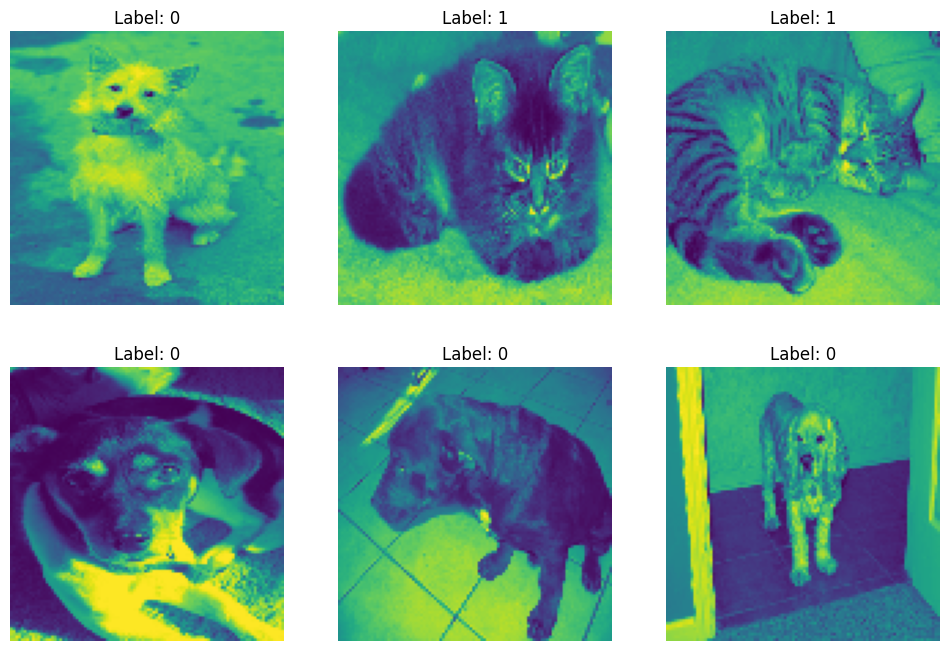

In [6]:
#Repeat and verify
indices = np.random.choice(len(image_array), 6, replace=False)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
  plt.subplot(2,3,i+1)
  plt.imshow(image_array[i])
  plt.title(f'Label: {target_array[i]}') #Look at y values
  plt.axis('off')

plt.savefig('Sample.png', dpi=300, bbox_inches='tight')

plt.show()

## Data Processing


###Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
  image_array,
  target_array,
  test_size=0.20,
  random_state=42
)

###Build Convolutional Neural Networks (CNN), Compile & Fit Keras Model

In [8]:
#Sequential layers (stacked)
model = Sequential()

#Define input layer with training data
model.add(Input(shape=X_train.shape[1:]))

#First Convolution Layer
model.add(
  Conv2D(
    name = 'Conv1',
    filters = 64,
    kernel_size = (3,3),
    activation='relu'            #Converts negative pixels to 0
  )
)

#Added after each convolution layer
model.add(MaxPooling2D(pool_size=(2,2)))

#Second Convolution Layer
model.add(
  Conv2D(
    name = 'Conv2',
    filters = 64,
    kernel_size = (3,3),
    activation='relu'
  )
)

model.add(MaxPooling2D(pool_size=(2,2)))

#Flatten to 1D
model.add(Flatten())

#Hidden layer to turn negative values to 0
model.add(
  Dense(
    units = 64,
    activation='relu'
  )
)

#Output layer
model.add(
  Dense(
    name = 'Output',
    units = 1,
    activation = 'sigmoid'
  )
)

#Compile Model
model.compile(
    optimizer='adam',           #Adjusts learning rates to update network weights efficiently
    loss='binary_crossentropy', #Measures how far model's predicted probability is from actual label (0 or 1)
    metrics=['accuracy']        #Tracks percentage of images classified correctly after each training step
)

#Fit Keras model
model.fit(
    X_train,
    y_train,
    epochs=10,                  #Number of times data will pass through model
    validation_split=0.10
)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5375 - loss: 0.6868 - val_accuracy: 0.5288 - val_loss: 0.7297
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6015 - loss: 0.6628 - val_accuracy: 0.6275 - val_loss: 0.6505
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6781 - loss: 0.5957 - val_accuracy: 0.6988 - val_loss: 0.5709
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7501 - loss: 0.5134 - val_accuracy: 0.7550 - val_loss: 0.5160
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7985 - loss: 0.4363 - val_accuracy: 0.7375 - val_loss: 0.5503
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8357 - loss: 0.3623 - val_accuracy: 0.7613 - val_loss: 0.5288
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8867 - loss: 0.2703 - val_accuracy: 0.7513 - val_loss: 0.6142
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9287 - loss: 0.1770 - val_accu

###Model Summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,613,445 (25.23 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,408,964 (16.82 MB)

###Evaluate Model

In [10]:
#Evaluate model using testing set
loss, accuracy = model.evaluate(X_test, y_test)
print()

#Binary Cross-Entropy Loss
print('Loss:', loss)         #Lower is better
print('Accuracy:', accuracy) #Percentage

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7220 - loss: 1.0786

Loss: 1.0786153078079224
Accuracy: 0.722000002861023


###Create Function to Read New Image

In [11]:
def prepare_image(filepath):

  img = image.load_img(         #Load image
      filepath,
      target_size=(100, 100),
      color_mode='grayscale'
  )

  img = image.img_to_array(img) #Convert to 3D np array
  img = img / 255.0             #Scale pixel values
  img = np.reshape(             #Convert to 4D array
    img,
    (1, 100, 100, 1)
  )

  return img

###Predict Unseen Image



In [12]:
image_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

#Download image
local_path = tf.keras.utils.get_file('dog.jpg', image_url)

def predict_image(filepath):
  test_image = prepare_image(filepath)
  probability = model.predict(test_image, verbose=0)[0][0]
  print()

  # Display prediction
  if probability > 0.5:
      label = 'Cat'
      confidence = probability
  else:
      label = 'Dog'
      confidence = 1 - probability

  print(f'Prediction: {label}')
  print(f'Confidence: {confidence:.1%}')

predict_image(local_path)


Prediction: Dog
Confidence: 83.6%


##Data Visualization

###Architecture Diagram

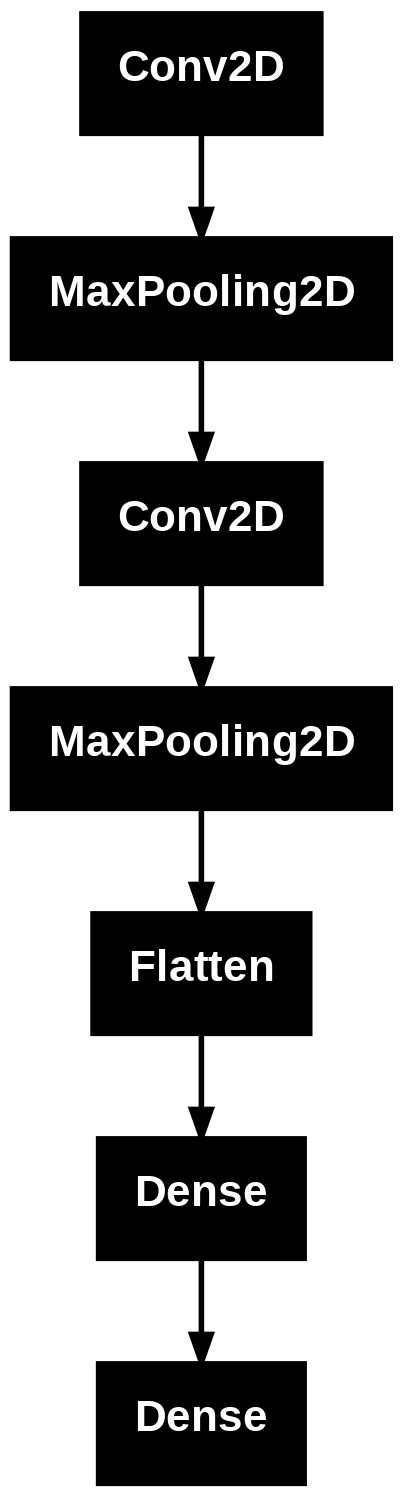

In [13]:
plot_model(model)

###Plot Distribution of Probabilities

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step



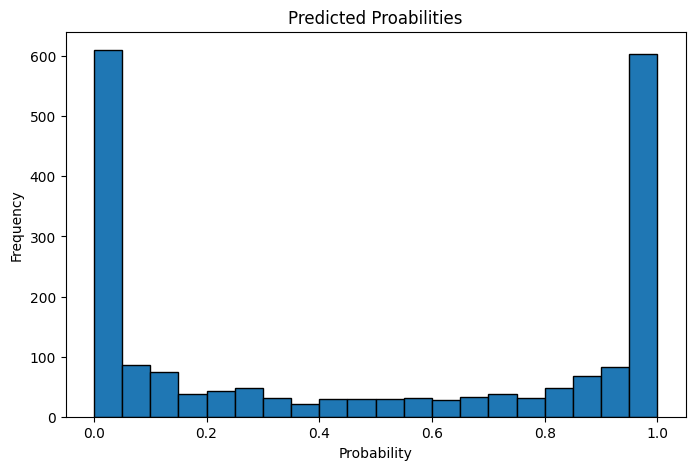

In [14]:
probabilities = model.predict(X_test)
print()

plt.figure(figsize=(8,5))

plt.hist(probabilities, bins=20, edgecolor='black')

plt.title('Predicted Proabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.tight_layout

plt.savefig('Predicted_Probabilities.png')

plt.show()

###Confusion Matrix

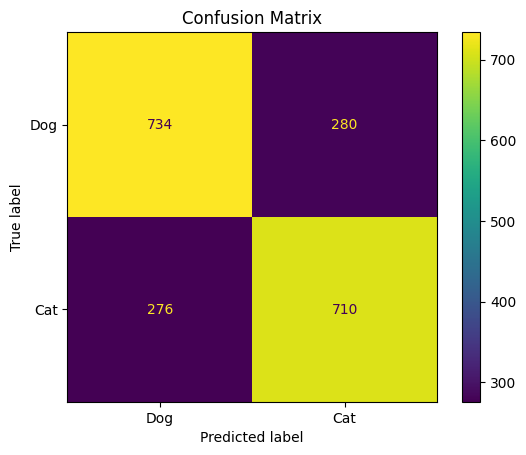

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = (probabilities > 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['Dog','Cat']
)

plt.title("Confusion Matrix")
plt.show()

###Odd Images

Found 58 odd/uncertain images.


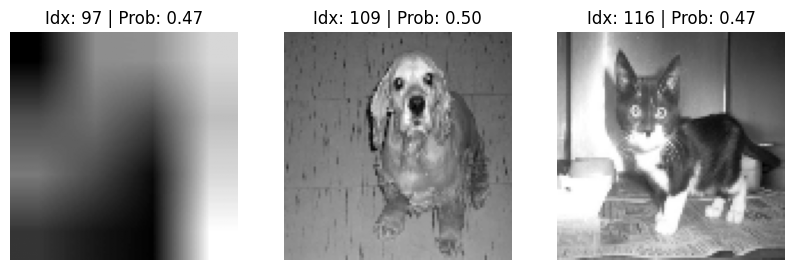

In [16]:
#Assign probability  X_test
probability = model.predict(X_test, verbose=0).flatten()

#Find indices where predicted probability is around 0.5 (uncertain/odd)
odd_idx = np.where((probability >= 0.45) & (probability <= 0.55))[0]

print(f"Found {len(odd_idx)} odd/uncertain images.")

#Plot and limit to 3 images
if len(odd_idx) > 0:
    plt.figure(figsize=(10, 4))
    for i, idx in enumerate(odd_idx[:3]):
        plt.subplot(1, min(3, len(odd_idx)), i + 1)
        plt.imshow(X_test[idx].squeeze(), cmap='gray')
        plt.title(f"Idx: {idx} | Prob: {probability[idx]:.2f}")
        plt.axis('off')
    plt.show()
else:
    print("No odd images found.")

##Communication of Results


Ran with 10,000 images, GPU

- Loss decreased and Accuracy increased from:

Loss: 1.415256381034851 / Accuracy: 0.6679999828338623

to

Loss: 1.0786153078079224 / Accuracy: 0.722000002861023

**View Data Visualization** to answer **Slack Questions:**
- How do distributions of probabilities change as # of images increase? Why?

- How do distributions of probabilities for each class change as # of images increase?

- Which images are dogs, but CNN identified with high probability of being a cat?

- Which images are cats, but CNN identified with high probability of being a dog?

- Did you find any images that looked ‘odd’ (couldn’t classify as dog or cat?) How did you identify them?


## **BONUS** - Upload Pet Image

In [17]:
# from google.colab import files

#Prompt user to upload image
# print('Upload picture: ')
# uploaded_pictures = files.upload()

#Loop through uploaded files
# for filename in uploaded_pictures.keys():
  # print(f'\n--- Analyzing {filename} ---')

  #Pass filename through function
  # predict_image(filename)